In [14]:
# ==========================================
# STEP 1: Data PREP
# ==========================================
import pandas as pd

# CSV Uploaded
file_path = 'nvda_stock_data_raw_nasdaq.csv'
df = pd.read_csv(file_path)

print("--- A QUICK LOOK AT THE RAW DATA ---")
print("Right now, the prices and volume are stuck as strings. We'll need to turn them into numbers next.")
print(df.info())
print("\nJust checking out the first few rows to see what we're working with:")
display(df.head(3))

# Cleaning
print("\n--- CLEANING ---")

# We strip out the dollar signs and commas so we can treat prices as floats.
price_columns = ['close', 'open', 'high', 'low']
for col in price_columns:
    df[col] = df[col].replace(r'[\$,]', '', regex=True).astype(float)

# Doing the same for volume, but turning it into an integer since you can't trade half a share.
df['volume'] = df['volume'].replace(r',', '', regex=True).astype(int)

# Converting the date column to actual datetime objects so Python understands time.
df['date'] = pd.to_datetime(df['date'])

# Sorting by date is super important for stock data, otherwise the timeline is all messed up.
df = df.sort_values('date').reset_index(drop=True)

# Just a quick check to see if any data is missing.
missing_count = df.isnull().sum()
print(f"\nMissing values found: {missing_count.sum()}")

--- A QUICK LOOK AT THE RAW DATA ---
Right now, the prices and volume are stuck as strings. We'll need to turn them into numbers next.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    2514 non-null   object
 1   close   2514 non-null   object
 2   volume  2514 non-null   object
 3   open    2514 non-null   object
 4   high    2514 non-null   object
 5   low     2514 non-null   object
dtypes: object(6)
memory usage: 118.0+ KB
None

Just checking out the first few rows to see what we're working with:


,date,close,volume,open,high,low
0,03/17/2026,$181.93,"182,497,800",$185.06,$185.40,$181.6804
1,03/16/2026,$183.22,"217,307,400",$182.97,$188.88,$181.41
2,03/13/2026,$180.25,"160,988,400",$184.92,$186.09,$179.94



--- CLEANING ---

Missing values found: 0


--- ADDING FEATURES ---
Done: Just added SMA_10, SMA_50, Daily_Return, and Volatility.


,date,close,volume,open,high,low,SMA_10,SMA_50,Daily_Return,Volatility_10d
2460,2026-03-11,186.03,145280400,185.91,187.62,184.4500,182.226,185.7080,0.006819,0.029198
2461,2026-03-12,183.14,155762700,184.05,184.94,181.7500,182.051,185.6064,-0.015535,0.023906
2462,2026-03-13,180.25,160988400,184.92,186.09,179.9400,182.357,185.4606,-0.015780,0.020075
2463,2026-03-16,183.22,217307400,182.97,188.88,181.4100,182.431,185.3950,0.016477,0.018379
2464,2026-03-17,181.93,182497800,185.06,185.40,181.6804,182.619,185.2566,-0.007041,0.017955



--- VISUALIZATION ---


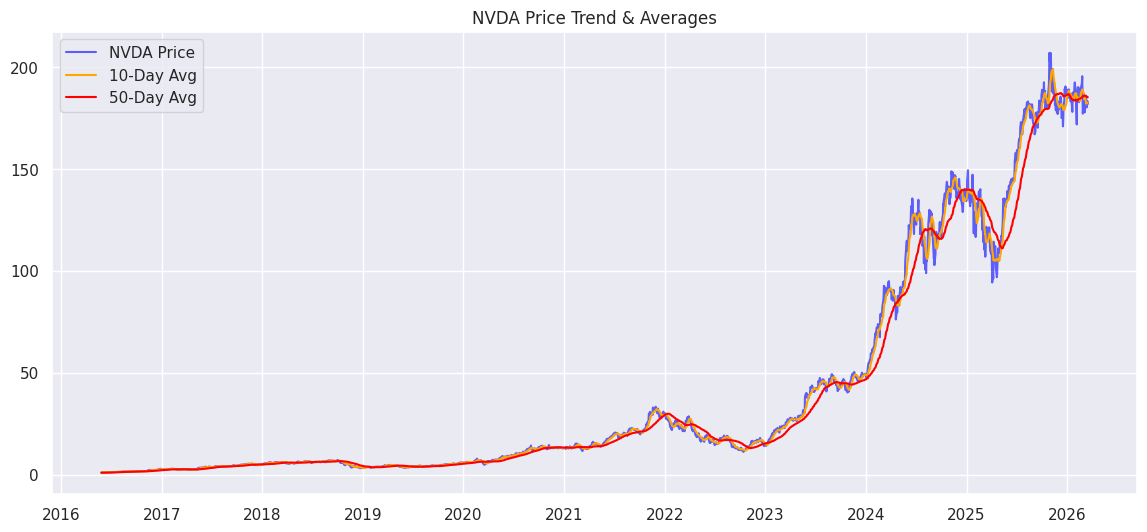

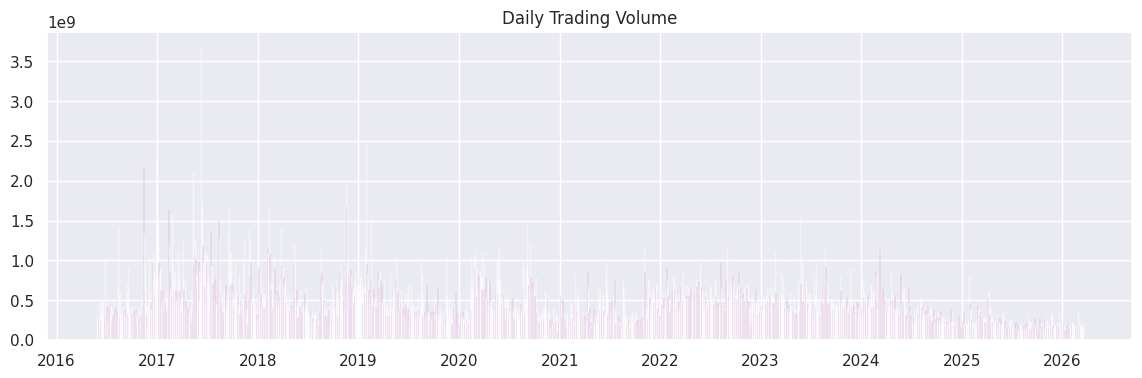

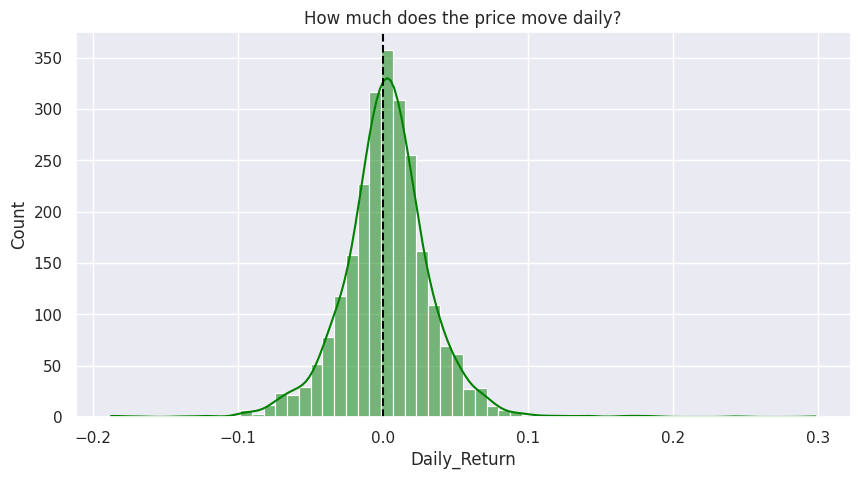

In [15]:
# ==========================================
# STEP 2: FEATURE ENGINEERING & DATA VIZ
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- ADDING FEATURES ---")
# Making a copy so we don't mess up the original dataframe.
eda_df = df.copy()

# Adding 10-day and 50-day moving averages to spot trends.
eda_df['SMA_10'] = eda_df['close'].rolling(window=10).mean()
eda_df['SMA_50'] = eda_df['close'].rolling(window=50).mean()

# Calculating the daily percent change to see how much it moves.
eda_df['Daily_Return'] = eda_df['close'].pct_change()

# Looking at 10-day volatility to gauge the risk.
eda_df['Volatility_10d'] = eda_df['Daily_Return'].rolling(window=10).std()

# Removing the empty rows caused due to the rolling windows.
eda_df = eda_df.dropna().reset_index(drop=True)

print("Done: Just added SMA_10, SMA_50, Daily_Return, and Volatility.")
display(eda_df.tail())

print("\n--- VISUALIZATION ---")
sns.set_theme(style="darkgrid")

# First plot: Price vs Moving Averages.
plt.figure(figsize=(14, 6))
plt.plot(eda_df['date'], eda_df['close'], label='NVDA Price', color='blue', alpha=0.6)
plt.plot(eda_df['date'], eda_df['SMA_10'], label='10-Day Avg', color='orange')
plt.plot(eda_df['date'], eda_df['SMA_50'], label='50-Day Avg', color='red')
plt.title('NVDA Price Trend & Averages')
plt.legend()
plt.show()

# Second plot: How many shares are being traded.
plt.figure(figsize=(14, 4))
plt.bar(eda_df['date'], eda_df['volume'], color='purple', alpha=0.5)
plt.title('Daily Trading Volume')
plt.show()

# Third plot: A histogram to see if the returns follow a normal curve.
plt.figure(figsize=(10, 5))
sns.histplot(eda_df['Daily_Return'], bins=60, kde=True, color='green')
plt.axvline(x=0, color='black', linestyle='--')
plt.title('How much does the price move daily?')
plt.show()

--- SETTING UP THE MACHINE LEARNING DATA ---
Training on 1971 days, testing on 493 days.

--- TRAINING THE RANDOM FOREST ---
Training Complete

--- Results ---
Overall Accuracy: 48.48%

Detailed breakdown:
              precision    recall  f1-score   support

           0       0.45      0.53      0.49       230
           1       0.52      0.45      0.48       263

    accuracy                           0.48       493
   macro avg       0.49      0.49      0.48       493
weighted avg       0.49      0.48      0.48       493



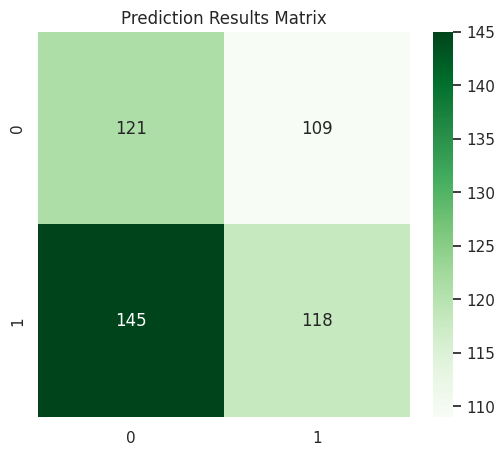

In [16]:
# ==========================================
# STEP 3: BUILDING THE PREDICTION MODEL
# ==========================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("--- SETTING UP THE MACHINE LEARNING DATA ---")
ml_df = eda_df.copy()

# We want to predict if the price goes up tomorrow.
# We'll use shift(-1) to look ahead one day.
ml_df['Next_Day_Close'] = ml_df['close'].shift(-1)
ml_df['Target'] = (ml_df['Next_Day_Close'] > ml_df['close']).astype(int)

# Drop the last row since we don't know the 'future' after the final day.
ml_df = ml_df.dropna().reset_index(drop=True)

features = ['SMA_10', 'SMA_50', 'Daily_Return', 'Volatility_10d']
X = ml_df[features]
y = ml_df['Target']

# Splitting the data manually because shuffling stock data would be cheating (data leakage).
split_index = int(len(ml_df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training on {len(X_train)} days, testing on {len(X_test)} days.")

print("\n--- TRAINING THE RANDOM FOREST ---")
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)
print("Training Complete")

print("\n--- Results ---")
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)
print(f"Overall Accuracy: {acc * 100:.2f}%")
print("\nDetailed breakdown:")
print(classification_report(y_test, preds))

# Visualizing the confusion matrix.
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Greens')
plt.title('Prediction Results Matrix')
plt.show()

In [17]:
# ==========================================
# STEP 4: INTERACTIVE PREDICTOR
# ==========================================
import time

def run_prediction():
    """This handles the logic for guessing tomorrow's move."""
    print("\nCrunching the numbers...")
    time.sleep(1) # Delay for user experience.

    latest_info = X.iloc[-1:]
    today_price = eda_df['close'].iloc[-1]

    print(f"Today's Price: ${today_price:.2f}")

    guess = model.predict(latest_info)

    if guess[0] == 1:
        print("The model thinks the price is going UP tomorrow.")
    else:
        print("The model is leaning towards a DROP tomorrow.")

def menu():a
    """Simple loop to keep the program running."""
    while True:
        print("\n--- NVDA PRICE PREDICTOR ---")
        print("1. Guess tomorrow's move")
        print("2. Show model stats")
        print("3. Quit")

        try:
            choice = input("What do you want to do? (1/2/3): ")

            if choice == '1':
                run_prediction()
            elif choice == '2':
                print(f"\nModel Accuracy: {accuracy * 100:.2f}%")
                print(f"Days Analyzed: {len(eda_df)}")
            elif choice == '3':
                print("\nSee ya later!")
                break
            else:
                print("\nWhoops, that's not an option. Try again.")
        except Exception as e:
            print(f"\nSomething went wrong: {e}")

# Let's start the app
menu()


--- NVDA PRICE PREDICTOR ---
1. Guess tomorrow's move
2. Show model stats
3. Quit
What do you want to do? (1/2/3): 2

Model Accuracy: 48.48%
Days Analyzed: 2465

--- NVDA PRICE PREDICTOR ---
1. Guess tomorrow's move
2. Show model stats
3. Quit
What do you want to do? (1/2/3): 1

Crunching the numbers...
Today's Price: $181.93
The model is leaning towards a DROP tomorrow.

--- NVDA PRICE PREDICTOR ---
1. Guess tomorrow's move
2. Show model stats
3. Quit
What do you want to do? (1/2/3): 2

Model Accuracy: 48.48%
Days Analyzed: 2465

--- NVDA PRICE PREDICTOR ---
1. Guess tomorrow's move
2. Show model stats
3. Quit
What do you want to do? (1/2/3): 3

See ya later!
